<a href="https://colab.research.google.com/github/dr-koehler-ai/Sepsis-Clinical-Analytics-Project-V1/blob/main/Sepsis_Dashboard_V1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Clinical Sepsis Analytics Dashboard (V1)
# =========================================

import kagglehub
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path


# =========================
# 1. Dataset Download
# =========================

dataset_path = kagglehub.dataset_download(
    "salikhussaini49/prediction-of-sepsis"
)

dataset_file = Path(dataset_path) / "Dataset.csv"

dataset_raw_df = pd.read_csv(dataset_file)


# =========================
# 2. Load dataset
# =========================
dataset_raw_df = pd.read_csv(
    "/root/.cache/kagglehub/datasets/salikhussaini49/prediction-of-sepsis/versions/2/Dataset.csv"
)

print("\nShape:", dataset_raw_df.shape)
print("\nColumns:", dataset_raw_df.columns.tolist())
print("\nPatients:", dataset_raw_df["Patient_ID"].nunique())

100%|██████████| 74.7M/74.7M [00:00<00:00, 209MB/s]

Extracting files...



Shape: (1552210, 44)

Columns: ['Unnamed: 0', 'Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel', 'Patient_ID']

Patients: 40336


**Missing Value Analysis and Dataset Aggegration**

In [6]:
# =========================
# 3. Missing Values Analysis
# =========================
missing = dataset_raw_df.isnull().mean().sort_values(ascending=False)
print("\nTop Missing Values:\n", missing.head(15))


clinical_rel_col = [
    'HR', 'Temp', 'MAP', 'Resp',
    'Creatinine', 'Lactate', 'WBC',
    'Platelets', 'O2Sat'
]

good_cols = missing[missing < 0.9].index
final_cols = list(set(good_cols) | set(clinical_rel_col))

dataset_clean = dataset_raw_df[final_cols]

# =========================
# 4. Patient-level aggregation
# =========================
dataset_agg = dataset_clean.groupby("Patient_ID").agg({
    "HR": ["mean", "max"],
    "O2Sat": ["mean", "min"],
    "Temp": ["mean", "min", "max"],
    "MAP": ["mean", "min"],
    "Resp": ["mean", "max"],
    "Lactate": ["mean", "max"],
    "WBC": ["mean", "max"],
    "Creatinine": "max",
    "Age": "first",
    "Gender": "first",
    "SepsisLabel": "max",
    'Platelets': 'mean'
})

# flatten columns
dataset_agg.columns = [
    f"{col[0]}_{col[1]}" if isinstance(col, tuple) else col
    for col in dataset_agg.columns
]

dataset_agg = dataset_agg.rename(columns={"SepsisLabel_max": "SepsisPatient"})


print("\nFinal dataset shape:", dataset_agg.shape)

dataset_agg.head()


Top Missing Values:
 Bilirubin_direct    0.998074
Fibrinogen          0.993402
TroponinI           0.990477
Bilirubin_total     0.985092
Alkalinephos        0.983932
AST                 0.983776
Lactate             0.973299
PTT                 0.970559
SaO2                0.965494
EtCO2               0.962868
Phosphate           0.959863
HCO3                0.958106
Chloride            0.954603
BaseExcess          0.945790
PaCO2               0.944401
dtype: float64

Final dataset shape: (40336, 20)


,HR_mean,HR_max,O2Sat_mean,O2Sat_min,Temp_mean,Temp_min,Temp_max,MAP_mean,MAP_min,Resp_mean,Resp_max,Lactate_mean,Lactate_max,WBC_mean,WBC_max,Creatinine_max,Age_first,Gender_first,SepsisPatient,Platelets_mean
Patient_ID,,,,,,,,,,,,,,,,,,,,
1,101.571429,117.0,91.477273,85.0,36.778000,36.11,37.44,87.261905,44.00,24.820000,32.0,NaN,NaN,10.200000,14.7,0.7,83.14,0,0,327.500000
2,60.954545,94.0,97.000000,94.0,36.165000,36.00,36.44,66.704545,50.50,14.236842,27.0,NaN,NaN,11.000000,11.0,2.5,75.91,0,0,158.000000
3,79.611111,93.0,95.431818,91.0,37.609375,36.89,38.61,81.048000,62.67,25.633333,40.0,NaN,NaN,9.000000,10.0,0.9,45.82,0,0,479.666667
4,102.444444,113.0,98.203704,95.5,36.455000,36.06,36.78,67.147308,34.00,18.884615,26.0,NaN,NaN,7.600000,7.6,0.8,65.71,0,0,182.000000
5,73.916667,88.0,97.500000,96.0,36.992222,36.22,37.33,87.088235,73.00,16.500000,21.0,NaN,NaN,6.933333,8.1,0.7,28.09,1,0,279.000000


In [7]:
dataset_agg = dataset_agg.reset_index()
dataset_agg.to_csv(
    "sepsis_patient_level_dataset.csv",
    index=False
)

import os
print(os.getcwd())

/content


**Data Validation**

In [5]:
# =========================
# 5. Data Validation
# =========================

dataset_agg.describe()

print("Continuous clinical variables were reviewed for implausible minimum and maximum values using descriptive statistics. All examined variables were found to be within clinically plausible physiological ranges, and no obvious data entry errors were identified.")

,Patient_ID,HR_mean,HR_max,O2Sat_mean,O2Sat_min,Temp_mean,Temp_min,Temp_max,MAP_mean,MAP_min,Resp_mean,Resp_max,Lactate_mean,Lactate_max,WBC_mean,WBC_max,Creatinine_max,Age_first,Gender_first,SepsisPatient
count,40336.000000,40331.000000,40331.000000,40318.000000,40318.000000,40052.000000,40052.000000,40052.000000,40232.000000,40232.000000,40265.000000,40265.000000,12493.000000,12493.000000,37711.000000,37711.000000,38287.000000,40336.000000,40336.000000,40336.000000
mean,59671.272858,83.805115,102.050078,97.153822,91.915856,36.842866,36.074296,37.480796,82.563081,64.574076,18.537966,26.240525,2.162096,2.715241,11.070723,12.364817,1.559972,61.643423,0.559451,0.072689
std,50251.337125,14.631989,19.257641,2.095486,6.725975,0.548194,0.685531,0.729604,12.579900,12.639757,3.405765,6.601625,1.750553,2.507642,6.586209,8.174087,1.996859,16.482946,0.496459,0.259629
min,1.000000,30.258065,37.000000,27.000000,20.000000,30.500000,20.900000,30.500000,22.000000,20.000000,1.000000,1.000000,0.300000,0.300000,0.100000,0.100000,0.100000,14.000000,0.000000,0.000000
25%,10084.750000,73.466667,89.000000,96.145161,91.000000,36.500000,35.700000,37.000000,73.583333,57.000000,16.380952,22.000000,1.220000,1.300000,7.600000,8.200000,0.740000,51.000000,0.000000,0.000000
50%,20475.500000,83.095238,100.000000,97.391304,93.000000,36.812404,36.100000,37.400000,80.818182,63.000000,18.142857,25.000000,1.700000,1.900000,10.200000,11.200000,0.980000,63.110000,1.000000,0.000000
75%,109916.250000,93.174166,114.000000,98.500000,95.000000,37.182727,36.500000,37.900000,90.000000,72.000000,20.279412,29.000000,2.460000,3.100000,13.300000,14.900000,1.400000,74.000000,1.000000,0.000000
max,120000.000000,174.697674,280.000000,100.000000,100.000000,39.737500,39.330000,50.000000,149.000000,140.000000,56.250000,100.000000,26.950000,31.000000,328.366667,440.000000,46.600000,100.000000,1.000000,1.000000


**Cohort Analysis**

The cohort analysis showed the distribution of patients developing sepsis during ICU stay. This baseline assessment was performed to evaluate outcome balance before comparing physiological characteristics between groups.

Total patients: 40336
Sepsis patients: 2932 (7.3%)
Non-sepsis patients: 37404 (92.7%)


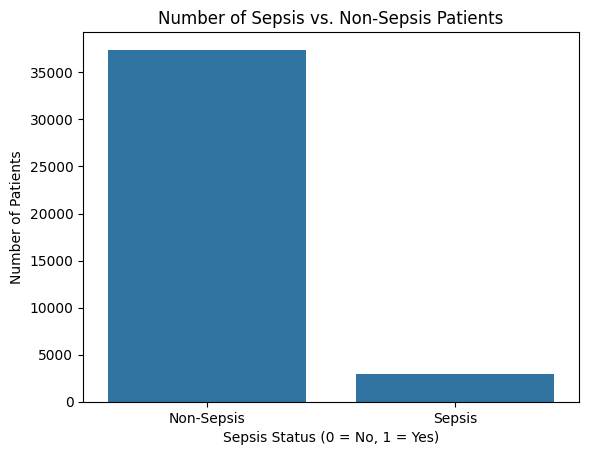

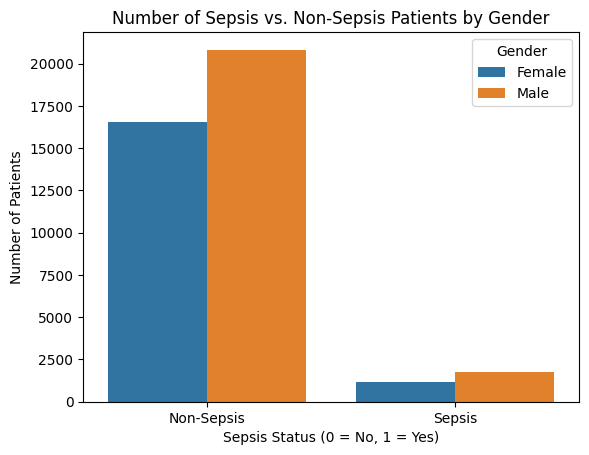

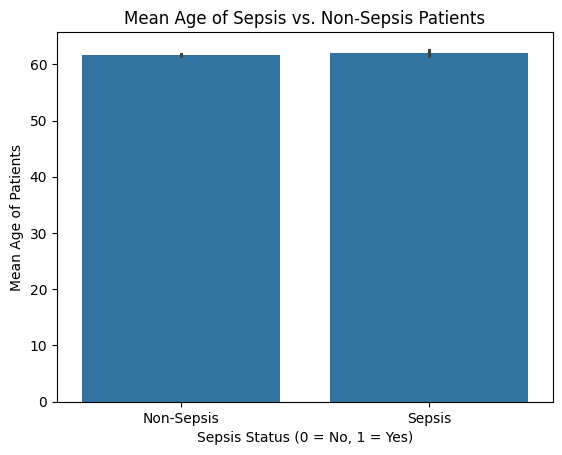

In [26]:
# =========================
# 6. Cohort Analysis
# =========================

total = len(dataset_agg)

sepsis = len(dataset_agg[dataset_agg["SepsisPatient"] == 1])
non_sepsis = len(dataset_agg[dataset_agg["SepsisPatient"] == 0])

print(f"Total patients: {total}")
print(f"Sepsis patients: {sepsis} ({sepsis/total:.1%})")
print(f"Non-sepsis patients: {non_sepsis} ({non_sepsis/total:.1%})")

sns.countplot(data=dataset_agg, x="SepsisPatient")
plt.title ("Number of Sepsis vs. Non-Sepsis Patients")
plt.xlabel("Sepsis Status (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")
plt.xticks(
    ticks=[0,1],
    labels=["Non-Sepsis", "Sepsis"]
)
plt.show()

sns.countplot(data=dataset_agg, x="SepsisPatient", hue="Gender_first")
plt.title ("Number of Sepsis vs. Non-Sepsis Patients by Gender")
plt.xlabel("Sepsis Status (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")
plt.xticks(
    ticks=[0,1],
    labels=["Non-Sepsis", "Sepsis"]
)
plt.legend(
    title="Gender",
    labels=["Female", "Male"]
)
plt.show()

sns.barplot(data=dataset_agg, x="SepsisPatient", y="Age_first", estimator="mean")
plt.title ("Mean Age of Sepsis vs. Non-Sepsis Patients")
plt.xlabel("Sepsis Status (0 = No, 1 = Yes)")
plt.ylabel("Mean Age of Patients")
plt.xticks(
    ticks=[0,1],
    labels=["Non-Sepsis", "Sepsis"]
)
plt.show()

7. **Univariate Analysis**

*Clinical question*:
How are the distributions of key clinical variables within the ICU cohort?

*Objective*:
Assess distribution shape, skewness, variability and potential outliers before comparing sepsis and non-sepsis patients.

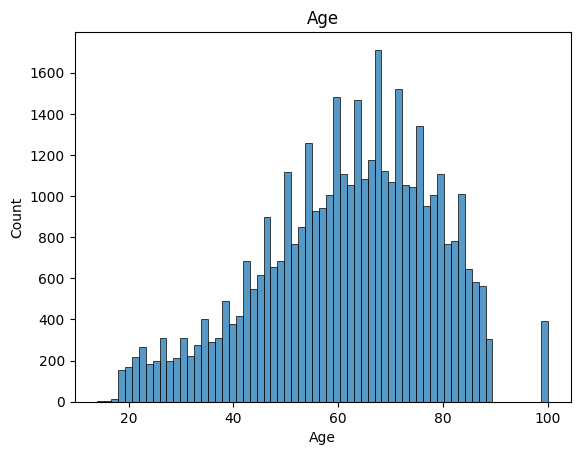

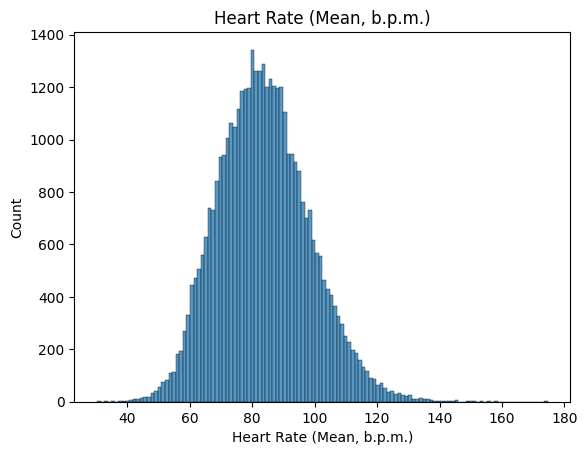

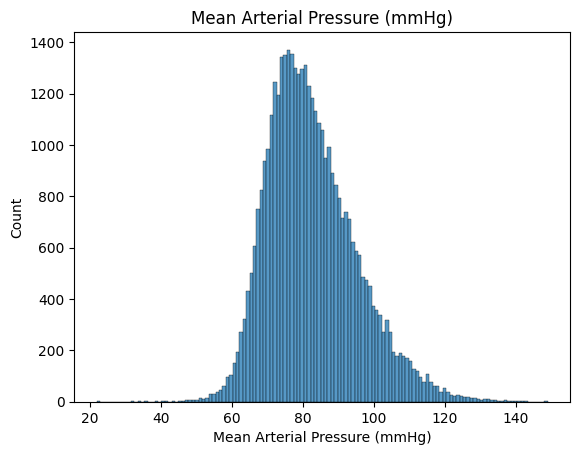

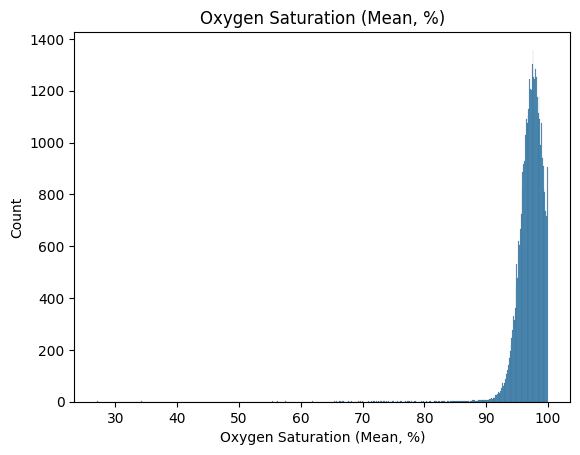

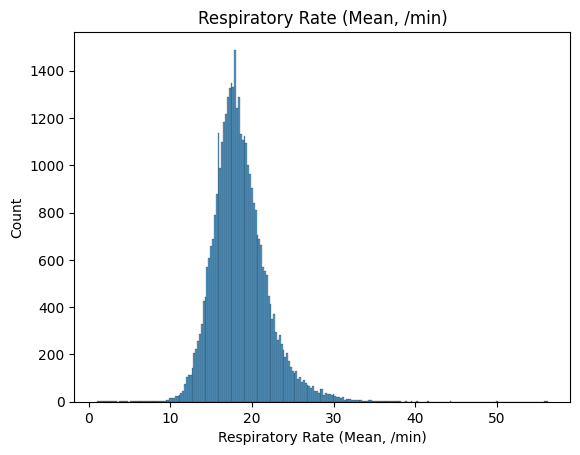

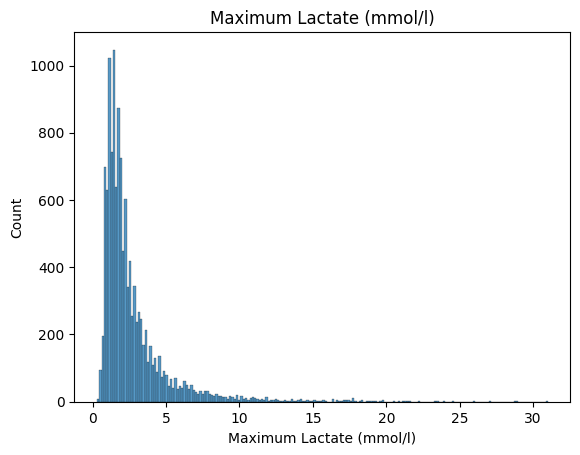

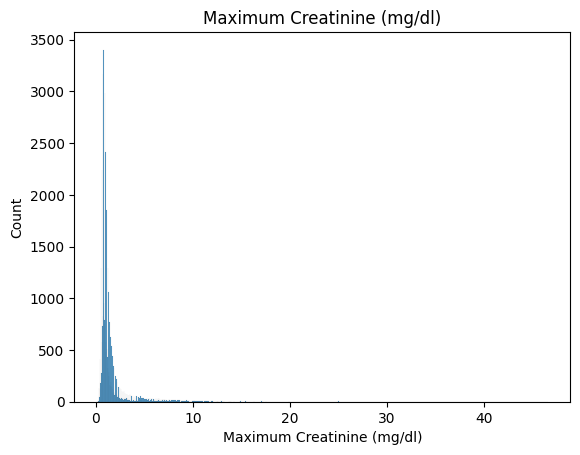

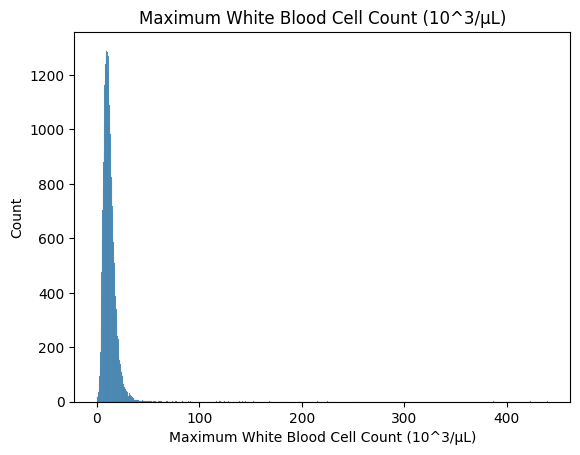

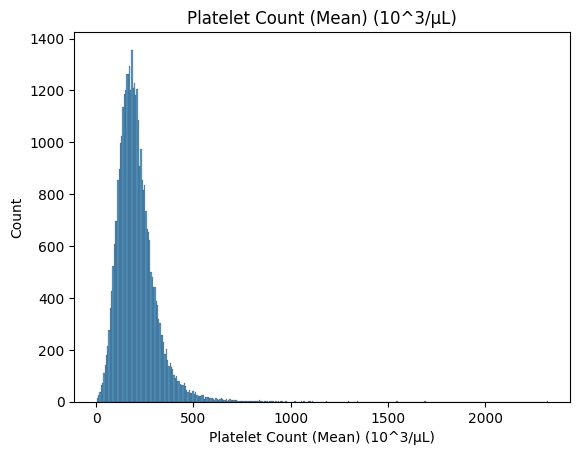

In [12]:
# =========================
# 7. Univeriat Analysis
# =========================

baseline_features = [
    "Age_first",
    "HR_mean",
    "MAP_mean",
    "O2Sat_mean",
    "Resp_mean",
    "Lactate_max",
    "Creatinine_max",
    "WBC_max",
    "Platelets_mean"
]

variable_labels = {
    "HR_mean": "Heart Rate (Mean, b.p.m.)",
    "MAP_mean": "Mean Arterial Pressure (mmHg)",
    "O2Sat_mean": "Oxygen Saturation (Mean, %)",
    "Resp_mean": "Respiratory Rate (Mean, /min)",
    "Lactate_max": "Maximum Lactate (mmol/l)",
    "Creatinine_max": "Maximum Creatinine (mg/dl)",
    "WBC_max": "Maximum White Blood Cell Count (10^3/µL)",
    "Platelets_mean": "Platelet Count (Mean) (10^3/µL)",
    "Age_first": "Age"
}

def var_histogramms(x):
  for feat in x:
    label = variable_labels.get(feat, feat)
    sns.histplot(data=dataset_agg, x=feat)
    plt.title(label)
    plt.xlabel(label)
    plt.show()
  return

var_histogramms(baseline_features)

**Clinical Characteristics by Sepsis Status**



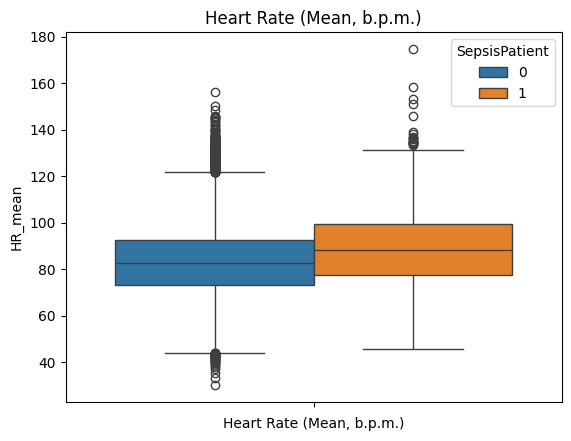

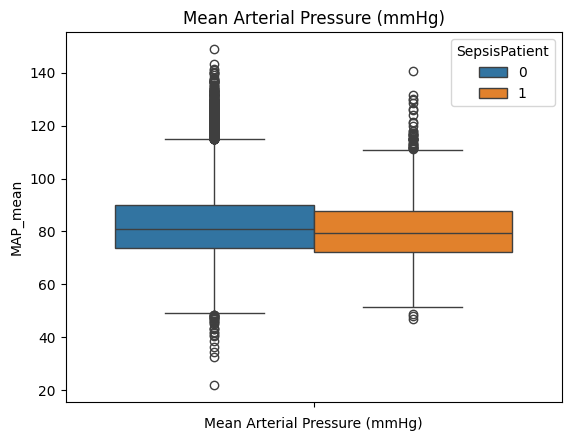

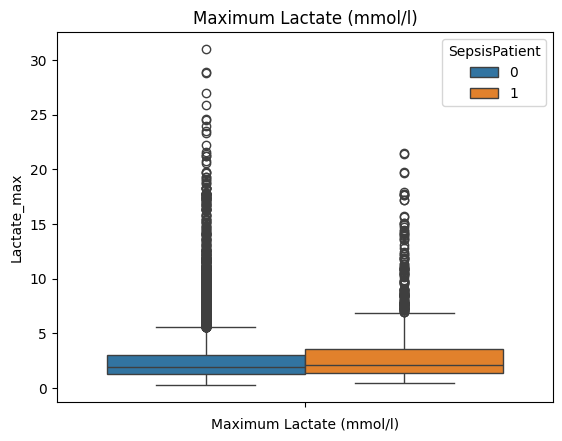

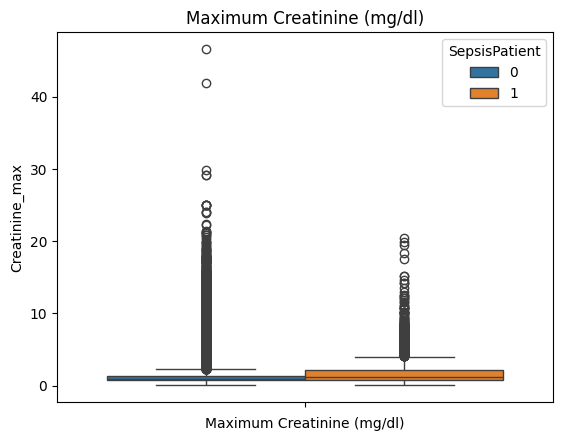

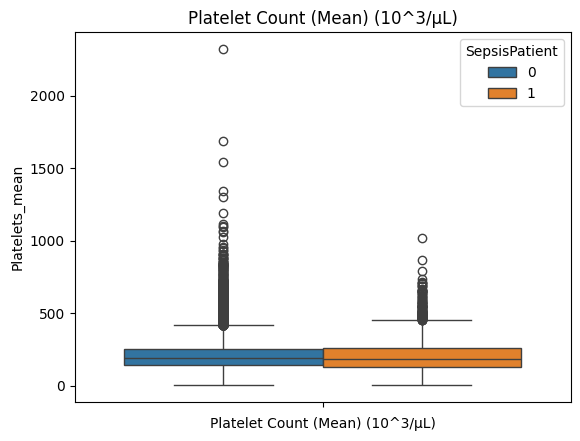

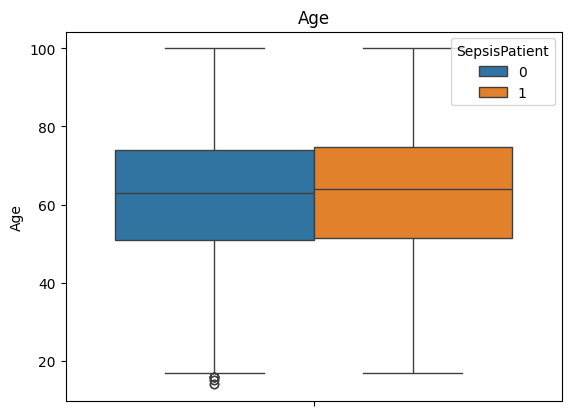

In [28]:
# ===================================================
# 8. Clinical Characteristics by Sepsis Status
# ===================================================

continious_features = [
    "HR_mean",
    "MAP_mean",
    "Lactate_max",
    "Creatinine_max",
    "Platelets_mean"
]

def var_boxplots(x):
  for feat in x:
    label = variable_labels.get(feat, feat)
    sns.boxplot(data=dataset_agg, y=feat, hue="SepsisPatient")
    plt.title(label)
    plt.xlabel(label)
    plt.show()
  return

var_boxplots(continious_features)

sns.boxplot(data=dataset_agg, y="Age_first", hue="SepsisPatient")
plt.title("Age")
plt.ylabel("Age")
plt.show()


=== Baseline Characteristics ===

                Non-Sepsis  Sepsis
Age_first            61.61   62.06
HR_mean              83.39   89.10
MAP_mean             82.72   80.54
O2Sat_mean           97.15   97.26
Resp_mean            18.45   19.64
Lactate_max           2.67    3.00
Creatinine_max        1.53    1.93
WBC_max              12.14   15.24
Platelets_mean      207.05  203.25

=== Gender Distribution (%) ===

SepsisPatient  Gender_first
0              1               55.7
               0               44.3
1              1               59.3
               0               40.7
Name: proportion, dtype: float64


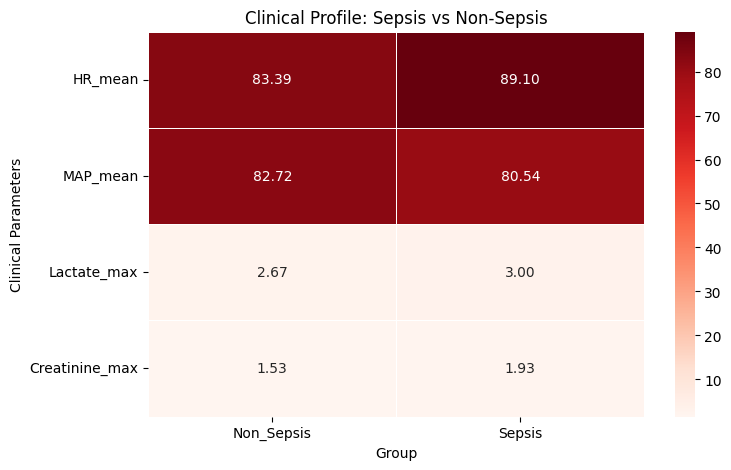

In [31]:
# =========================
# 8. Summary Table
# =========================

baseline_table = dataset_agg.groupby("SepsisPatient")[baseline_features].mean().T

baseline_table.columns = [
    "Non-Sepsis",
    "Sepsis"
]

print("\n=== Baseline Characteristics ===\n")
print(baseline_table.round(2))

gender_table = (
    dataset_agg
    .groupby("SepsisPatient")["Gender_first"]
    .value_counts(normalize=True)
    .mul(100)
)

print("\n=== Gender Distribution (%) ===\n")
print(gender_table.round(1))


# =========================
# 9. Final Heatmap
# =========================
plt.figure(figsize=(8, 5))

sns.heatmap(
    comparison_df,
    annot=True,
    cmap="Reds",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Clinical Profile: Sepsis vs Non-Sepsis")
plt.ylabel("Clinical Parameters")
plt.xlabel("Group")
plt.show()